https://www.who.int/teams/environment-climate-change-and-health/water-sanitation-and-health/water-safety-and-quality/drinking-water-quality-guidelines

# 1. Import libraries

In [2]:
!pip install geostatspy statsmodels geostatsmodels numba

In [3]:
import os                                                     # for file and directory operations
import numpy as np                                            # for numerical operations and ndarrays
import pandas as pd                                           # for handling data in DataFrame format
import matplotlib.pyplot as plt                               # for plotting and visualization
from statsmodels.stats.weightstats import DescrStatsW         # for weighted statistics calculations
from scipy.optimize import curve_fit                          # for curve fitting
import geostatspy.GSLIB as GSLIB                              # GSLIB utilities, visualization, and wrapper functions
import geostatspy.geostats as geostats                        # GSLIB methods converted to Python 
import geostatspy                                             # for accessing the package version and general utilities
print('GeostatsPy version: ' + str(geostatspy.__version__))   # print the version of GeostatsPy

from tqdm import tqdm                                         # progress bar for loops
from functools import partialmethod                           # used to modify tqdm to suppress the status bar
tqdm.__init__ = partialmethod(tqdm.__init__, disable=True)    # suppress the status bar for tqdm

from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control over axes ticks in plots
plt.rc('axes', axisbelow=True)                                # ensure grid lines are plotted below plot elements

import scipy.spatial as sp                                    # for spatial data structures and algorithms (KDTree)
import geopandas as gpd                                       # for handling geospatial data (GeoDataFrame)
from matplotlib import gridspec                               # custom subplots

# Define ignore_warnings before using it
ignore_warnings = True                                        # flag to ignore warnings

# Check and apply the warning filter
if ignore_warnings == True:                                   
    import warnings
    warnings.filterwarnings('ignore')

from IPython.utils import io                                  # mute output from simulation

cmap = "Spectral_r"                                           # color map


GeostatsPy version: 0.0.78


# 2. Create Folders to store data and results

In [4]:
current_path =os.getcwd()
current_path

'C:\\Users\\Glen\\Dropbox\\2025_PGDip_Data_Science\\Week 3\\Week_3_Practicals'

In [5]:
def add_grid():
    plt.gca().grid(True, which='major',linewidth = 1.0); plt.gca().grid(True, which='minor',linewidth = 0.2) # add y grids
    plt.gca().tick_params(which='major',length=7); plt.gca().tick_params(which='minor', length=4)
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator()); plt.gca().yaxis.set_minor_locator(AutoMinorLocator()) # turn on minor ticks   

In [6]:
# Set the path for the images directory
image_path = 'images'
results_path = 'results'
input_path = 'input_data'
model_path = 'models'
# Check if the images directory already exists
if not os.path.exists(image_path):
    # Create the images directory
    os.mkdir(image_path)
else:
    print('Image directory already exists')

# Check if the file directory already exists
if not os.path.exists(results_path):
    # Create the file directory
    os.mkdir(results_path)
else:
    print('Results directory already exists')
    
# Check if the file directory already exists
if not os.path.exists(input_path):
    # Create the file directory
    os.mkdir(input_path)
else:
    print('Input Data directory already exists')
    
    
    # Check if the file directory already exists
if not os.path.exists(model_path):
    # Create the file directory
    os.mkdir(model_path)
else:
    print('Model Path directory already exists')

print('Image directory is -', image_path)
print('Results directory is -', results_path)
print('Input Data directory is -', input_path)
print('Model Path directory is -', model_path)

Image directory already exists
Results directory already exists
Input Data directory already exists
Model Path directory already exists
Image directory is - images
Results directory is - results
Input Data directory is - input_data
Model Path directory is - models


# 3. Load database

In [7]:
df_As = pd.read_csv(current_path+'\\input_data\\Synthetic_Arsenic_Data_FF.csv')    
df_As 

,EAST,NORTH,As
0,273.041475,779.883382,23.533643
1,351.382489,791.545189,22.402858
2,358.294931,706.997085,21.052205
3,197.004608,849.854227,20.723272
4,330.645161,794.460641,18.726256
...,...,...,...
148,72.580645,704.081633,0.592105
149,109.447005,520.408163,0.444079
150,505.760369,319.241983,0.296053
151,717.741935,167.638484,0.148026


In [8]:
df_As.columns

Index(['EAST', 'NORTH', 'As'], dtype='object')

We can preview the DataFrame by printing a slice or by utilizing the 'head' DataFrame member function (with a nice and clean format, see below). 

* With the slice we could look at any subset of the data table and with the head command, add parameter 'n=3' to see the first 3 rows of the dataset. 

In [9]:
df_As.head()

,EAST,NORTH,As
0,273.041475,779.883382,23.533643
1,351.382489,791.545189,22.402858
2,358.294931,706.997085,21.052205
3,197.004608,849.854227,20.723272
4,330.645161,794.460641,18.726256


# 4. Check Descriptive Stats and Create Spatial Plot

#### Summary Statistics for Tabular Data

The table includes EAST and NORTH coordinates (meters), and As (ppb). 

There are a lot of efficient methods to calculate summary statistics from tabular data in DataFrames. 

* The describe command provides count, mean, minimum, maximum, and quartiles all in a nice data table. 

* We use transpose just to flip the table so that features are on the rows and the statistics are on the columns.

In [10]:
df_As.describe().T

,count,mean,std,min,25%,50%,75%,max
EAST,153.0,513.546279,255.252932,38.018433,296.082949,544.930876,729.262673,950.460830
NORTH,153.0,518.350197,263.779482,16.034985,293.002915,459.183673,794.460641,934.402332
As,153.0,12.607239,7.339387,0.148026,6.799152,12.765743,19.286184,23.533643


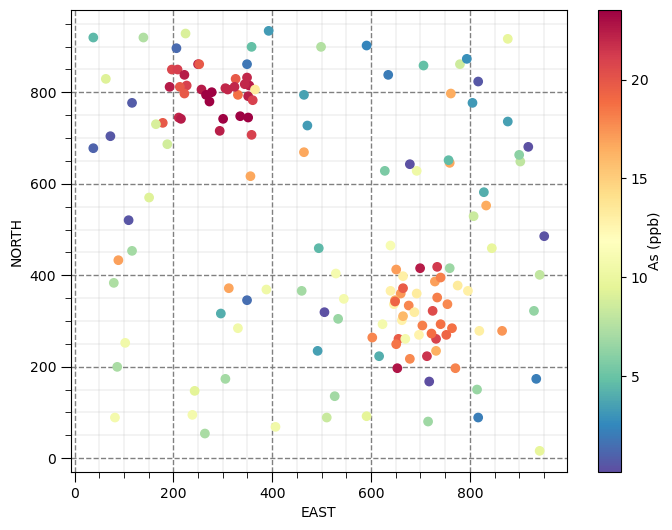

In [11]:

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create the scatter plot
sc = ax.scatter(df_As['EAST'], df_As['NORTH'], c=df_As['As'], cmap=cmap)

# Create the grid
ax.grid(True, color='grey', linestyle='--', linewidth=0.5)

# Add labels to the axes
ax.set_xlabel('EAST')
ax.set_ylabel('NORTH')

# Add a colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('As (ppb)', rotation=90, labelpad=0)
cbar.ax.tick_params(labelsize=10)
add_grid()
# Save the figure
fig.savefig(current_path+"\\images\\As_spatial_location_of_samples.png", dpi=300, bbox_inches='tight')


# Display the plot
plt.show()


# 5. Decluster Samples

This is a tutorial for / demonstration of **Spatial Data Declustering**. 

**YouTube Lecture**: check out my lecture on [Sources of Spatial Bias](https://youtu.be/w0HgVibxpMQ?si=8sOBf4sUIRqfvOc7) and [Spatial Data Declustering](https://youtu.be/rN0RKcTIVcI?si=6EOJvDKEplGtkXKD). For your convenience here's a summary of slalient points.

#### Geostatistical Sampling Representativity

In general, we should assume that all spatial data that we work with is biased.

##### Source of Spatial Sampling Bias

Data is collected to answer questions:
* how far does the contaminant plume extend? – sample peripheries
* where is the fault? – drill based on seismic interpretation
* what is the highest mineral grade? – sample the best part
* who far does the reservoir extend? – offset drilling
and to maximize NPV directly:
* maximize production rates

**Random Sampling**: when every item in the population has a equal chance of being chosen. Selection of every item is independent of every other selection.
Is random sampling sufficient for subsurface?  Is it available?
* it is not usually available, would not be economic
* data is collected answer questions
    * how large is the reservoir, what is the thickest part of the reservoir 
* and wells are located to maximize future production
    * dual purpose appraisal and injection / production wells!

**Regular Sampling**: when samples are taken at regular intervals (equally spaced).  
* less reliable than random sampling.
* Warning: may resonate with some unsuspected environmental variable.

What do we have?
* we usually have biased, opportunity sampling 
* we must account for bias (debiasing will be discussed later)

So if we were designing sampling for representativity of the sample set and resulting sample statistics, by theory we have 2 options, random sampling and regular sampling.

* What would happen if you proposed random sampling in the Gulf of Mexico at $150M per well?

We should not change current sampling methods as they result in best economics, we should address sampling bias in the data.

Never use raw spatial data without access sampling bias / correcting.

##### Mitigating Sampling Bias

##### Cell-based Declustering

Place a cell mesh over the data and share the weight over each cell. Data in densely sampled areas or volumes will get less weight while data in sparsely sampled areas or volumes will get more weight.

Cell-based declustering weights are calculated by first identifying the cell that the data occupies, $\ell$, then,

$$
w(\bf{𝐮}_j) = \frac{1}{n_{\ell}} \cdot \frac{n}{L_o}
$$

where $n_{\ell}$ is the number of data in the $\ell$ cell standardized by the ratio of $n$ is the total number of data divided by $L_o$ number of cells with data. As a result the sum of all weights is $n$ and nominal weight is 1.0. 

Additional considerations:

* influence of cell mesh origin is removed by averaging the data weights over multiple random cell mesh origins
* the optimum cell size is selected by minimizing or maximizing the declustered mean, based on whether the means is biased high or low respectively

In this demonstration we will take a biased spatial sample data set and apply declustering using **GeostatsPy** functionality.

#### Load the required libraries

The following code loads the required libraries. 

This is a tutorial for / demonstration of **Spatial Data Declustering**. 

**YouTube Lecture**: check out my lecture on [Sources of Spatial Bias](https://youtu.be/w0HgVibxpMQ?si=8sOBf4sUIRqfvOc7) and [Spatial Data Declustering](https://youtu.be/rN0RKcTIVcI?si=6EOJvDKEplGtkXKD). The methods demonstrated here include:

* cell-based declustering
* polygonal declustering
* kriging-based declustering

#### Geostatistical Sampling Representativity

In general, we should assume that all spatial data that we work with is sampled in a biased manner. Why? ...

##### Source of Spatial Sampling Bias

Data is collected to answer questions:
* how far does the contaminant plume extend? – sample peripheries
* where is the fault? – drill based on seismic interpretation
* what is the highest mineral grade? – sample the best part
* who far does the reservoir extend? – offset drilling
and to maximize NPV directly:
* maximize production rates

**Random Sampling**: when every item in the population has a equal chance of being chosen. Selection of every item is independent of every other selection.
Is random sampling sufficient for subsurface?  Is it available?
* it is not usually available, would not be economic
* data is collected answer questions
    * how large is the reservoir, what is the thickest part of the reservoir 
* and wells are located to maximize future production
    * dual purpose appraisal and injection / production wells!

**Regular Sampling**: when samples are taken at regular intervals (equally spaced).  
* less reliable than random sampling.
* Warning: may resonate with some unsuspected environmental variable.

What do we have?
* we usually have biased, opportunity sampling 
* we must account for bias (debiasing will be discussed later)

So if we were designing sampling for representativity of the sample set and resulting sample statistics, by theory we have 2 options, random sampling and regular sampling.

* What would happen if you proposed random sampling in the Gulf of Mexico at $150M per well?

We should not change current sampling methods as they result in best economics, we should address sampling bias in the data.

Never use raw spatial data without access sampling bias / correcting.

#### Mitigating Sampling Bias

Here's a summary of all the methods:

##### Cell-based Declustering

Place a cell mesh over the data and share the weight over each cell. Data in densely sampled areas or volumes will get less weight while data in sparsely sampled areas or volumes will get more weight.

Cell-based declustering weights are calculated by first identifying the cell that the data occupies, $\ell$, then,

\begin{equation}
w(\bf{𝐮}_j) = \frac{1}{n_{\ell}} \cdot \frac{n}{L_o}
\end{equation}

where $n_{\ell}$ is the number of data in the $\ell$ cell standardized by the ratio of $n$ is the total number of data divided by $L_o$ number of cells with data. As a result the sum of all weights is $n$ and nominal weight is 1.0. 

Additional considerations:

* influence of cell mesh origin is removed by averaging the data weights over multiple random cell mesh origins
* the optimum cell size is selected by minimizing or maximizing the declustered mean, based on whether the means is biased high or low respectively

In this demonstration we will take a biased spatial sample data set and apply declustering using **GeostatsPy** functionality. 

##### Polygonal-based Declustering

Assign Voronoi poloygons to the data within the area or volume of interest. Then apply data weights proportional to the area or volume of the associated Voronoi polygon and standardized by the totol area or volume.

\begin{equation}
w(\bf{𝐮}_j) = \frac{a_j}{A} \cdot n
\end{equation}

Additional considerations:

* this method is very sensitive to the area or volume boundary

##### Kriging-based Declustering

Assign a grid over the area or volume of interest and perform kriging. While performing kriging, sum the weight assigned to each data over all the grid cells. Assign declustering weights as the sum of kriging weights standardized by the total number of data divided by the total kriging weight over all data and grid cells. 

\begin{equation}
w(\bf{𝐮}_j) = \sum_{i_y = 1}^{n_y} \sum_{i_x = 1}^{n_x} \lambda_{j,ix,iy} \cdot \frac{n}{\sum \lambda}
\end{equation}

Additional considerations:

* this method is sensitive to the grid extends and integrates the concept of spatial continuity through the variogram.
* high resolution grids will increase accuracy but takes longer to calculate 

#### Load the required libraries

The following code loads the required libraries.

In [12]:
df_As["declust_weight"], cell_size, declust_means = geostats.declus(df_As,'EAST','NORTH','As',iminmax = 1, noff= 25, ncell=200,cmin=1,cmax=750)


There are 153 data with:
   mean of      12.607238646281045 
   min and max  0.148026316 and 23.5336433
   standard dev 7.3153626173819815 


Now let's look at the plot of the declustered porosity mean vs. the declustering cell size over the 100 runs. At very small and very large cell size the declustered mean is the naive mean. 

naive mean = 12.607
declustered mean = 9.01
Plot saved to C:\Users\Glen\Dropbox\2025_PGDip_Data_Science\Week 3\Week_3_Practicals\images\As_declustered_mean_vs_cell_size.png


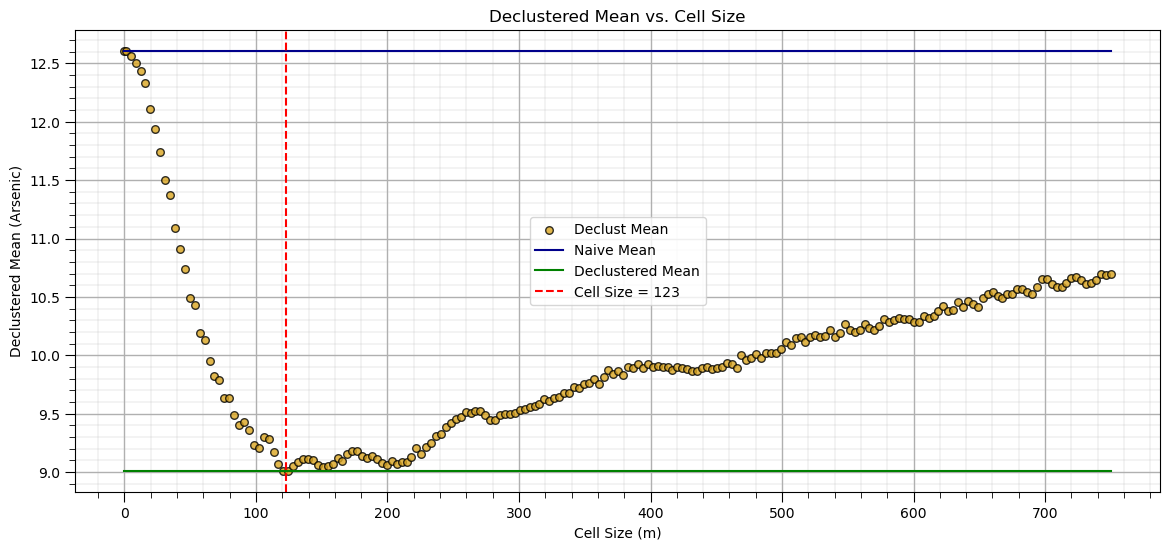

In [13]:
# Calculating the weighted mean (declustered mean)
weighted_data = DescrStatsW(df_As["As"].values, weights=df_As["declust_weight"].values, ddof=0)
dmean = round(weighted_data.mean, 3)

# Calculating the naive mean for comparison
naive_mean = round(np.mean(df_As["As"].values), 3)
print("naive mean = " +str(naive_mean))
print("declustered mean = " +str(dmean))
# Create a scatter plot
plt.figure(figsize=(14, 6))
plt.scatter(cell_size, declust_means, s=30, alpha=0.8, edgecolors="black", facecolors='goldenrod', label='Declust Mean')
plt.plot(cell_size, [naive_mean] * len(cell_size), color='darkblue', label='Naive Mean')
plt.plot(cell_size, [dmean] * len(cell_size), color='green', label='Declustered Mean')

# Plotting a vertical red dotted line at cell size 123
plt.axvline(x=123, color='red', linestyle='--', label='Cell Size = 123')

# Labels, title, and grid
plt.xlabel('Cell Size (m)')
plt.ylabel('Declustered Mean (Arsenic)')
plt.title('Declustered Mean vs. Cell Size')

plt.legend()
add_grid()
# Save the plot
save_path = current_path+'\\images\\As_declustered_mean_vs_cell_size.png'
plt.savefig(save_path)
print(f"Plot saved to {save_path}")

# Show the plot
plt.show()


In [14]:
df_As.head(3)

,EAST,NORTH,As,declust_weight
0,273.041475,779.883382,23.533643,0.254363
1,351.382489,791.545189,22.402858,0.286090
2,358.294931,706.997085,21.052205,0.743607


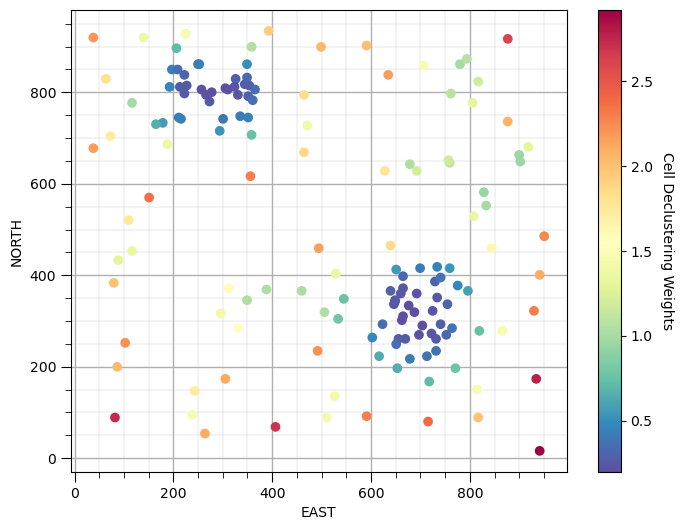

In [15]:

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create the scatter plot
sc = ax.scatter(df_As['EAST'], df_As['NORTH'], c=df_As['declust_weight'], cmap='Spectral_r')


# Add labels to the axes
ax.set_xlabel('EAST')
ax.set_ylabel('NORTH')

# Add a colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Cell Declustering Weights', rotation=270, labelpad=15)
cbar.ax.tick_params(labelsize=10)
add_grid()
# Save the figure
fig.savefig(current_path+"\\images\\declustering_weights.png", dpi=300, bbox_inches='tight')


# Display the plot
plt.show()


In [16]:
# Calculate naive statistics
naive_stats = df_As['As'].describe(percentiles=[0.25, 0.75])

# Calculate declustered statistics using weighted statistics
declust_mean = weighted_data.mean
declust_min = np.min(df_As['As'].values)
declust_q1 = weighted_data.quantile(0.25).item()  # Convert to scalar using item()
declust_q3 = weighted_data.quantile(0.75).item()  # Convert to scalar using item()
declust_max = np.max(df_As['As'].values)

# Construct the table data
table_data = {
    "Arsenic Data": ["Naive", "Declustered", "Difference"],
    "Min [ppb]": [round(naive_stats['min'], 2), round(declust_min, 2), round(declust_min - naive_stats['min'], 2)],
    "Q1 [ppb]": [round(naive_stats['25%'], 2), round(declust_q1, 2), round(declust_q1 - naive_stats['25%'], 2)],
    "Mean [ppb]": [round(naive_stats['mean'], 2), round(declust_mean, 2), round(declust_mean - naive_stats['mean'], 2)],
    "Q3 [ppb]": [round(naive_stats['75%'], 2), round(declust_q3, 2), round(declust_q3 - naive_stats['75%'], 2)],
    "Max [ppb]": [round(naive_stats['max'], 2), round(declust_max, 2), round(declust_max - naive_stats['max'], 2)]
}

# Create a DataFrame for the table
summary_table_df = pd.DataFrame(table_data)
summary_table_df.to_excel(current_path+"\\results\\comparison_unbiased.xlsx")
summary_table_df


,Arsenic Data,Min [ppb],Q1 [ppb],Mean [ppb],Q3 [ppb],Max [ppb]
0,Naive,0.15,6.80,12.61,19.29,23.53
1,Declustered,0.15,4.06,9.01,10.92,23.53
2,Difference,0.00,-2.74,-3.60,-8.36,0.00


# 6. Transform Data to Gaussian Space

This is a tutorial for / demonstration of **Distribution Transformations**. 

**YouTube Lecture**: check out my lecture on [Distribution Transformations](https://youtu.be/ZDIpE3OkAIU?si=H1KY-KDswVlEFyZh). For your convenience here's a summary of slalient points.

Here's a simple workflow with some basic univariate distribution transformations for subsurface modeling workflows. This should help you get started data transformations.  

#### Data Distribution Transformations

Why?:
* variable has expected shape / correcting for too few data
* a specific distribution assumption is required
* correct for outliers

How?:

There are a variety of transformations. In general we are transforming the values from the cumulative distribution function (CDF), $F_{X}$, to a new CDF , $G_{Y}$. This can be generalized with the quantile - quantile transformation applied to all the sample data:   

* The forward transform:

\begin{equation}
Y = G_{Y}^{-1}(F_{X}(X))
\end{equation}

* The reverse transform:

\begin{equation}
X = F_{X}^{-1}(G_{Y}(Y))
\end{equation}

This may be applied to any data, nonparametric or samples from a parametric distribution. We just need to be able to map from one distribution to another through percentiles, so it is a:

* Rank preserving transform

We will cover three examples including:

1. Distribution rescaling
2. Normal score transform

#### Load the required libraries

The following code loads the required libraries. 

In [17]:
df_As["nscore"], tv, tns = geostats.nscore(df_As, "As", "declust_weight")
df_As

,EAST,NORTH,As,declust_weight,nscore
0,273.041475,779.883382,23.533643,0.254363,2.836082
1,351.382489,791.545189,22.402858,0.286090,1.850594
2,358.294931,706.997085,21.052205,0.743607,1.566967
3,197.004608,849.854227,20.723272,0.433933,1.479477
4,330.645161,794.460641,18.726256,0.239041,1.307368
...,...,...,...,...,...
148,72.580645,704.081633,0.592105,1.717515,-1.503908
149,109.447005,520.408163,0.444079,1.754903,-1.672587
150,505.760369,319.241983,0.296053,1.038988,-1.990344
151,717.741935,167.638484,0.148026,0.726756,-2.278125


In [18]:
feature = "As"
feature_units = "ppb"
vmin=df_As["As"].min()
vmax=df_As["As"].max()
xmin=df_As["EAST"].min()
xmax=df_As["EAST"].max()
ymin=df_As["NORTH"].min()
ymax=df_As["NORTH"].max()

Does it look correct?  See the weight varies with local sampling density?  

Now let's add the distribution of the weights and the naive and declustered porosity distributions. You should see the histogram bars adjusted by the weights. Also note the change in the mean due to the weights. There is a significant change.

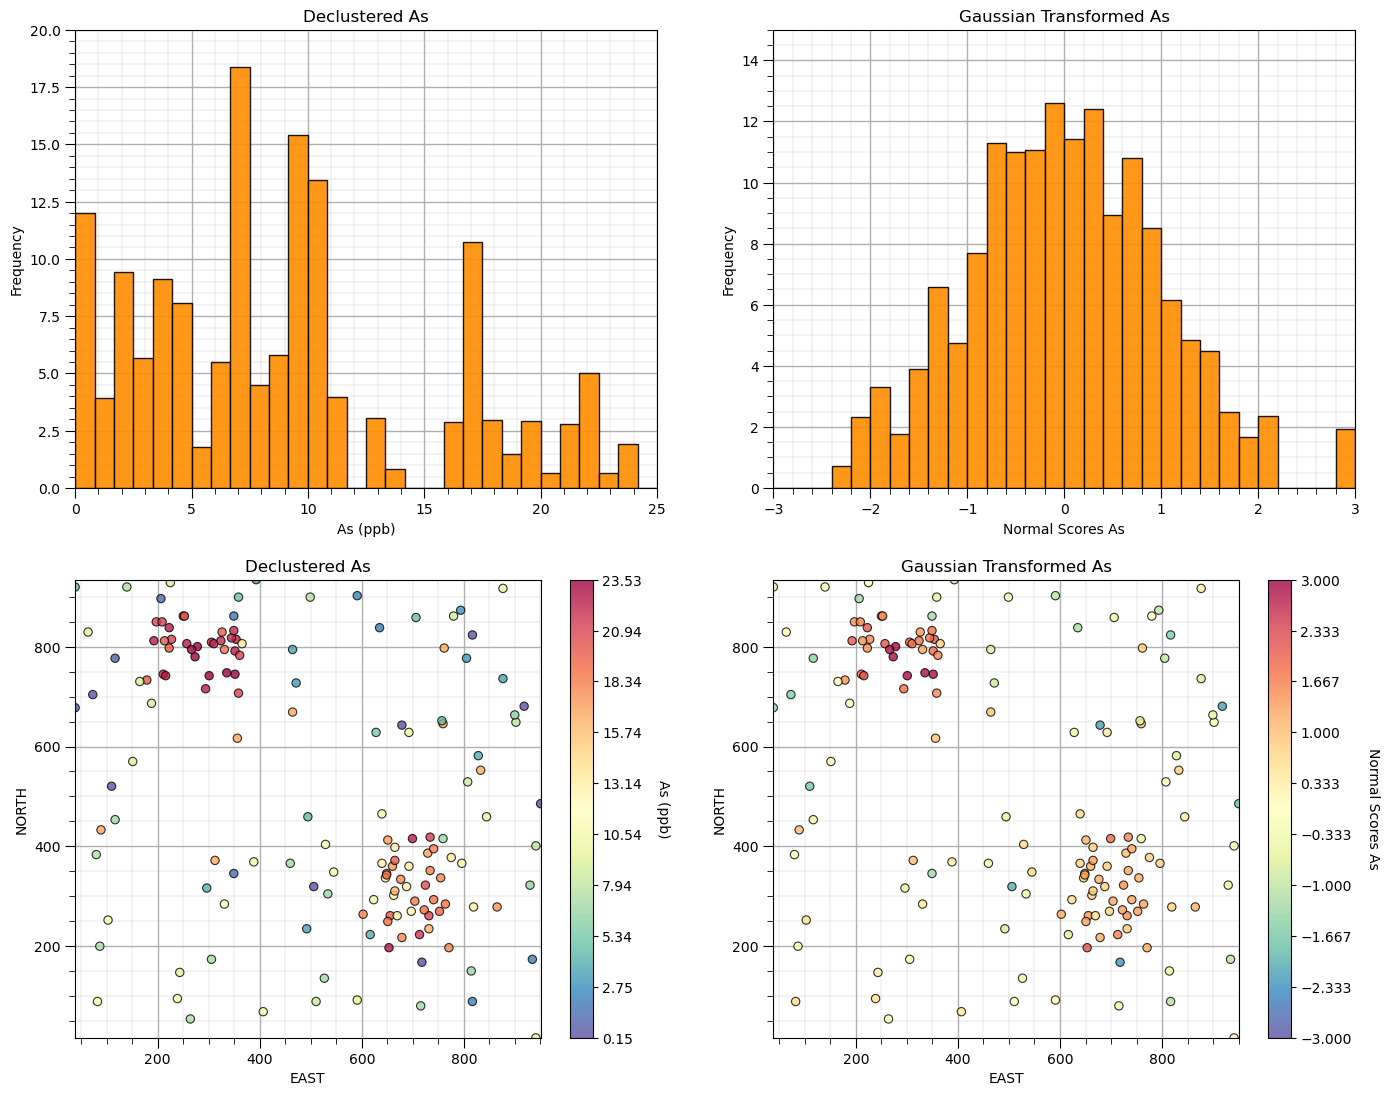

In [19]:
plt.subplot(221)
GSLIB.hist_st(df_As['As'],0,25,log=False,cumul=False,bins=30,weights=df_As['declust_weight'],xlabel="As (ppb)",title="Declustered As")
plt.ylim(0.0,20)
add_grid()
plt.subplot(222)
GSLIB.hist_st(df_As['nscore'],-3.0,3.0,log=False,cumul=False,bins=30,weights=df_As['declust_weight'],xlabel="Normal Scores As",title="Gaussian Transformed As")
plt.ylim(0.0,15)
add_grid()
plt.subplot(223)
GSLIB.locmap_st(df_As,'EAST','NORTH','As',xmin,xmax,ymin,ymax,vmin,vmax,'Declustered As','EAST','NORTH','As (ppb)',cmap)
add_grid()
plt.subplot(224)
GSLIB.locmap_st(df_As,'EAST','NORTH','nscore',xmin,xmax,ymin,ymax,-3.0,3.0,'Gaussian Transformed As','EAST','NORTH','Normal Scores As',cmap)
add_grid()
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=2.1, wspace=0.2, hspace=0.2)
plt.show()

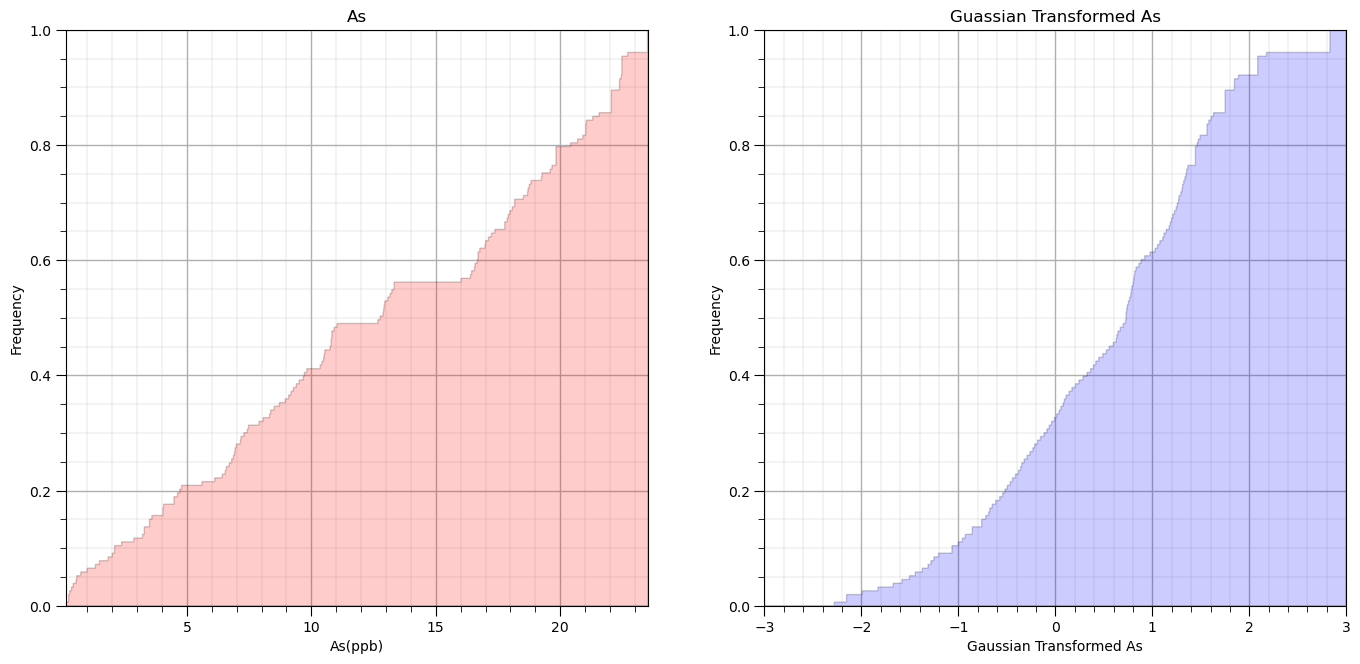

In [20]:
plt.subplot(121)  

plt.hist(df_As[feature], facecolor='red',bins=np.linspace(vmin,vmax,1000),histtype="stepfilled",alpha=0.2,density=True,cumulative=True,edgecolor='black')
plt.xlim([vmin,vmax]); plt.ylim([0,1.0])
plt.xlabel(feature + '(' + feature_units + ')'); plt.ylabel('Frequency'); plt.title('As')
add_grid()

plt.subplot(122)  
plt.hist(df_As['nscore'], facecolor='blue',bins=np.linspace(-3.0,3.0,1000),histtype="stepfilled",alpha=0.2,density=True,cumulative=True,edgecolor='black')
plt.xlim([-3.0,3.0]); plt.ylim([0,1.0])
plt.xlabel('Gaussian Transformed ' + feature); plt.ylabel('Frequency'); plt.title('Guassian Transformed ' + feature)
add_grid()

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.2, wspace=0.2, hspace=0.3)
plt.show()

In [21]:
df_As.describe().T.to_excel(current_path+"\\results\\As_summary_stats.xlsx")

## p-value

### What is a p-value?

A **p-value** is a measure used in statistical hypothesis testing to help you decide whether to reject the null hypothesis. It represents the probability of obtaining test results at least as extreme as the results actually observed, under the assumption that the null hypothesis is true.

### Interpretation of p-values

- **Small p-value (typically ≤ 0.05):** This indicates strong evidence against the null hypothesis, so you reject the null hypothesis. In other words, the observed data is unlikely under the assumption that the null hypothesis is true.
  
- **Large p-value (typically > 0.05):** This suggests weak evidence against the null hypothesis, so you fail to reject the null hypothesis. This means the observed data is consistent with the null hypothesis.

### Example in Normality Testing

When testing whether a dataset follows a Gaussian (normal) distribution:

- **Null Hypothesis (H0):** The data is normally distributed.
- **Alternative Hypothesis (H1):** The data is not normally distributed.

If you perform a normality test and obtain a p-value:

- **p-value ≤ 0.05:** You reject the null hypothesis, concluding that the data is not normally distributed.
- **p-value > 0.05:** You fail to reject the null hypothesis, meaning there isn't sufficient evidence to say the data is not normally distributed, so you assume it is.

### Important Notes

- The p-value alone does not confirm that a hypothesis is true or false; it only provides a measure of the strength of the evidence against the null hypothesis.
- The threshold (typically 0.05) is arbitrary and depends on the field of study or the specific context.
- A small p-value indicates that the observed data would be very unlikely under the null hypothesis, while a large p-value suggests that the data is quite likely under the null hypothesis.

plt.hist?

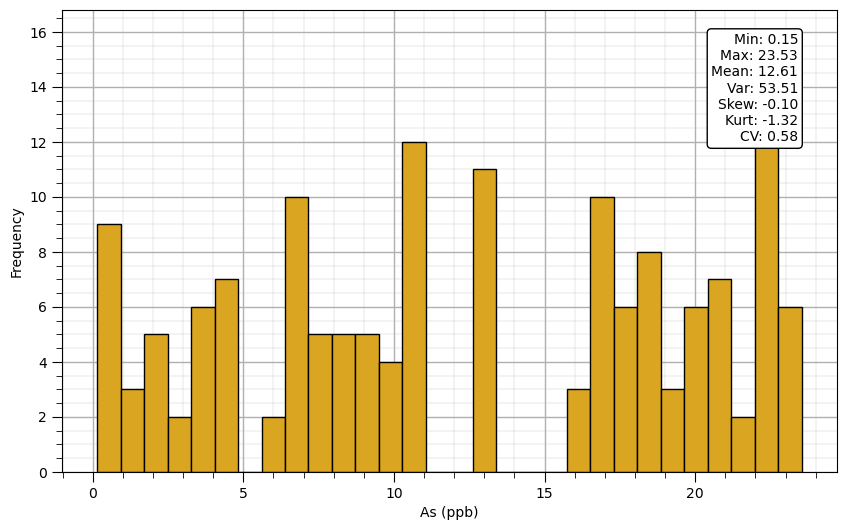

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew

# Calculate statistics
As_data = df_As["As"]
min_val = np.min(As_data)
max_val = np.max(As_data)
mean_val = np.mean(As_data)
var_val = np.var(As_data)
skew_val = skew(As_data)
kurt_val = kurtosis(As_data)
cv_val = np.std(As_data) / mean_val

# Prepare the stats text
stats_text = (f"Min: {min_val:.2f}\n"
              f"Max: {max_val:.2f}\n"
              f"Mean: {mean_val:.2f}\n"
              f"Var: {var_val:.2f}\n"
              f"Skew: {skew_val:.2f}\n"
              f"Kurt: {kurt_val:.2f}\n"
              f"CV: {cv_val:.2f}")

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the histogram
ax.hist(As_data, bins=30, edgecolor="black", color="goldenrod")

ax.set_xlabel("As (ppb)")
ax.set_ylabel("Frequency")

# Add the stats text box
ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))
add_grid()
# Save the figure
fig.savefig(current_path+"\\images\\raw_data_histogram.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [23]:
from scipy.stats import normaltest

# Assuming df_As is defined and contains the "nscore" column
raw_data = df_As["As"]

# Perform the normality test (D'Agostino and Pearson's test)
stat, p_value = normaltest(raw_data)

# Define the hypothesis result
alpha = 0.05
if p_value > alpha:
    result = "Fail to reject the null hypothesis (As grade is Gaussian)."
else:
    result = "Reject the null hypothesis (As grade is not Gaussian)."

p_value, result


(np.float64(1.6933710977494636e-28),
 'Reject the null hypothesis (As grade is not Gaussian).')

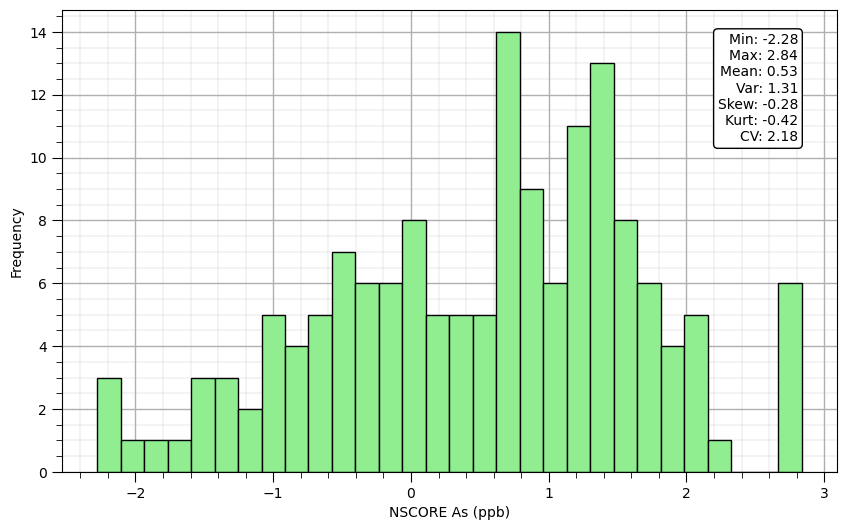

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew

# Calculate statistics for the "nscore" column
nscore_data = df_As["nscore"]
min_val = np.min(nscore_data)
max_val = np.max(nscore_data)
mean_val = np.mean(nscore_data)
var_val = np.var(nscore_data)
skew_val = skew(nscore_data)
kurt_val = kurtosis(nscore_data)
cv_val = np.std(nscore_data) / mean_val

# Prepare the stats text
stats_text = (f"Min: {min_val:.2f}\n"
              f"Max: {max_val:.2f}\n"
              f"Mean: {mean_val:.2f}\n"
              f"Var: {var_val:.2f}\n"
              f"Skew: {skew_val:.2f}\n"
              f"Kurt: {kurt_val:.2f}\n"
              f"CV: {cv_val:.2f}")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the histogram
ax.hist(nscore_data, bins=30, edgecolor="black", color="lightgreen")

ax.set_xlabel("NSCORE As (ppb)")
ax.set_ylabel("Frequency")

# Add the stats text box
ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))
add_grid()
# Save the figure
fig.savefig(current_path+"\\images\\nscore_data_histogram.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [25]:
from scipy.stats import normaltest

# df_As is defined and contains the "nscore" column
nscore_data = df_As["nscore"]

# Perform the normality test (D'Agostino and Pearson's test)
stat, p_value = normaltest(nscore_data)

# Define the hypothesis result
alpha = 0.05
if p_value > alpha:
    result = "Fail to reject the null hypothesis (nscore is Gaussian)."
else:
    result = "Reject the null hypothesis (nscore is not Gaussian)."

p_value, result


(np.float64(0.19170872555041288),
 'Fail to reject the null hypothesis (nscore is Gaussian).')

# 7. Variography

This is a tutorial for / demonstration of **Permissible Variogram Models**. 

**YouTube Lecture**: check out my lecture on [Variogram Modeling](https://youtu.be/-Bi63Y3u6TU?si=-kwvFLicNTbg85xL).

#### Variogram Models

Here I provide visualizations with the functions for the common positive definite variogram models. I variogram model inferred to represent spatial continuity from the variogram.

##### Spatial Continuity 

**Spatial Continuity** is the correlation between values over distance.

* No spatial continuity – no correlation between values over distance, random values at each location in space regardless of separation distance.

* Homogenous phenomenon have perfect spatial continuity, since all values as the same (or very similar) they are correlated. 

We need a statistic to quantify spatial continuity! A convenient method is the Semivariogram.

##### The Variogram

Function of difference over distance.

* The expected (average) squared difference between values separated by a lag distance vector (distance and direction), $h$:

$$
\gamma(\bf{h}) = \frac{1}{2 N(\bf{h})} \sum^{N(\bf{h})}_{\alpha=1} (z(\bf{u}_\alpha) - z(\bf{u}_\alpha + \bf{h}))^2  
$$

where $z(\bf{u}_\alpha)$ and $z(\bf{u}_\alpha + \bf{h})$ are the spatial sample values at tail and head locations of the lag vector respectively.

* Calculated over a suite of lag distances to obtain a continuous function.

* the $\frac{1}{2}$ term converts a variogram into a semivariogram, but in practice the term variogram is used instead of semivariogram.
* We prefer the semivariogram because it relates directly to the covariance function, $C_x(\bf{h})$ and univariate variance, $\sigma^2_x$:

$$
C_x(\bf{h}) = \sigma^2_x - \gamma(\bf{h})
$$

Note the correlogram is related to the covariance function as:

\begin{equation}
\rho_x(\bf{h}) = \frac{C_x(\bf{h})}{\sigma^2_x}
\end{equation}

The correlogram provides of function of the $\bf{h}-\bf{h}$ scatter plot correlation vs. lag offset $\bf{h}$.  

$$
-1.0 \le \rho_x(\bf{h}) \le 1.0
$$

##### Variogram Observations

The following are common observations for variograms that should assist with their practical use.

###### Observation \#1 - As distance increases, variability increase (in general).

This is common since in general, over greater distance offsets, there is often more difference between the head and tail samples.

In some cases, such as with spatial cyclicity of the hole effect variogram model the variogram may have negative slope over somelag distance intervals

Negative slopes at lag distances greater than half the data extent are often caused by too few pairs for a reliable variogram calculation

###### Observation \#2 - Calculated with over all possible pairs separated by lag vector, $\bf{𝐡}$.

We scan through the entire data set, searching for all possible pair combinations with all other data.  We then calculate the variogram as one half the expectation of squared difference between all pairs.

More pairs results in a more reliable measure.

###### Observation \#3 - Need to plot the sill to know the degree of correlation.

**Sill** is the variance, $\sigma^2_x$

Given stationarity of the variance, $\sigma^2_x$, and variogram $\gamma(\bf{h})$:

we can define the covariance function:

$$
C_x(\bf{h}) = \sigma^2_x - \gamma(\bf{h})
$$

The covariance measure is a measure of similarity over distance (the mirror image of the variogram as shown by the equation above).

Given a standardized distribution $\sigma^2_x = 1.0$, the covariance, $C_x(\bf{h})$, is equal to the correlogram, $\rho_x(\bf{h})$: 

\begin{equation}
\rho_x(\bf{h}) = \sigma^2_x - \gamma(\bf{h})
\end{equation}

###### Observation \#4 - The lag distance at which the variogram reaches the sill is know as the range.

At the range, knowing the data value at the tail location provides no information about a value at the head location of the lag distance vector.

###### Observation \#5 - The nugget effect, a discontinuity at the origin

Sometimes there is a discontinuity in the variogram at distances less than the minimum data spacing.  This is known as **nugget effect**.

The ratio of nugget / sill, is known as relative nugget effect (%). Modeled as a discontinuity with no correlation structure that at lags, $h \gt \epsilon$, an infinitesimal lag distance, and perfect correlation at $\bf{h} = 0$.
Caution when including nuggect effect in the variogram model as measurement error, mixing populations cause apparent nugget effect

This exercise demonstrates the semivariogram calculation with GeostatsPy. The steps include:

1. generate a 2D model with sequential Gaussian simulation
2. sample from the simulation
3. calculate and visualize experimental semivariograms

#### Detecting Directions of Continuity

Spatial continuity can be described with nested spatial continuity models:

$$
\Gamma_x(\bf{h}) = \sum_{i=1}^{nst} \gamma_i(\bf{h})
$$

where $\Gamma_x(\bf{h})$ is the nested variogram model resulting from the summation of $nst$ nested variograms  $\gamma_i(\bf{h})$.

Each one of these variogram structures, $\gamma_i(\bf{h})$, is based on a geometric anisotropy model parameterized by the orientation and range in the major and minor directions.  In 2D this is simply an azimuth and ranges, $azi$, $a_{maj}$ and $a_{min}$. Note, the range in the minor direction (orthogonal to the major direction.

The geometric anisotropy model assumes that the range in all off-diagonal directions is based on an ellipse with the major and minor axes alligned with and set to the major and minor for the variogram.

\begin{equation}
\bf{h}_i = \sqrt{\left(\frac{r_{maj}}{a_{maj_i}}\right)^2 + \left(\frac{r_{maj}}{a_{maj_i}}\right)^2}  
\end{equation}

Therefore, if we know the major direction, range in major and minor directions, we may completely describe each nested componnent of the complete spatial continuity of the variable of interest, $i = 1,\dots,nst$.

In this workflow we will observe the common permissible variogram models in GeostatsPy.  

* for all we assume a contribution of the sill (single structure) and the sill is 1.0 (standardized feature).

#### Load the required libraries

The following code loads the required libraries.

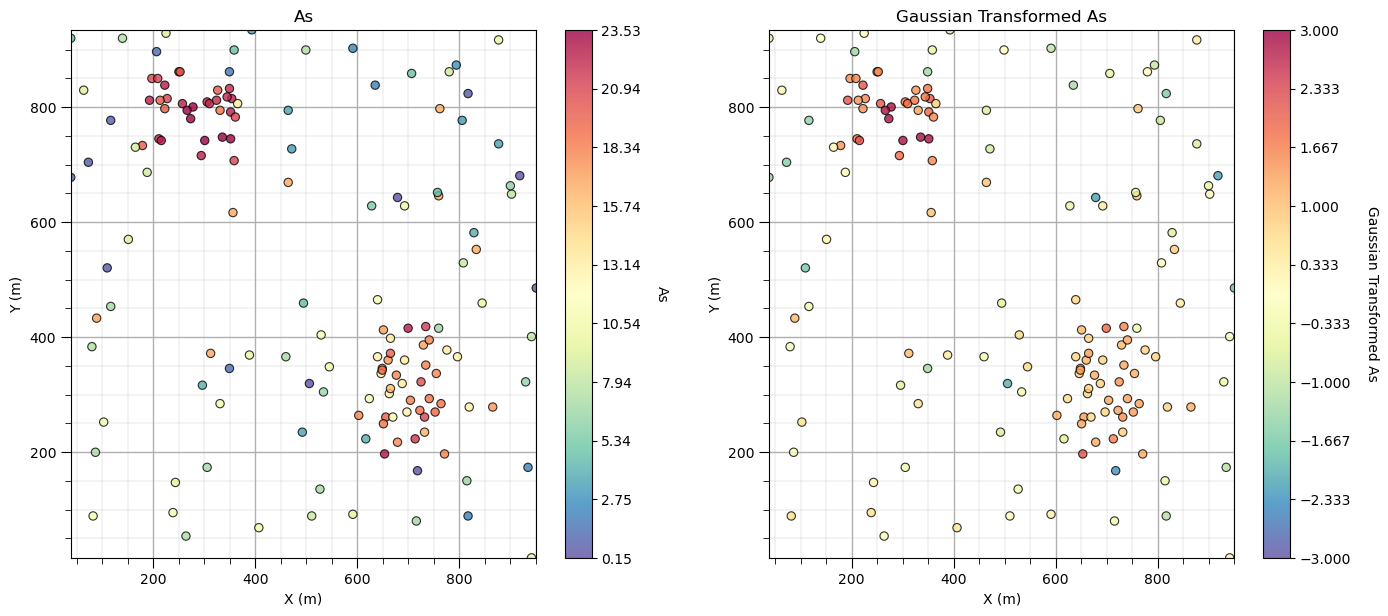

In [26]:
cmap = "Spectral_r"
plt.subplot(121)                                        # location map of normal score transform of ore grade
GSLIB.locmap_st(df_As,'EAST','NORTH',feature,xmin,xmax,ymin,ymax,vmin,vmax,feature,'X (m)','Y (m)',feature,cmap)
add_grid()
plt.subplot(122)                                        # location map of normal score transform of ore grade
GSLIB.locmap_st(df_As,'EAST','NORTH','nscore',xmin,xmax,ymin,ymax,-3,3,'Gaussian Transformed ' + feature,'X (m)','Y (m)','Gaussian Transformed ' + feature,cmap)
add_grid()
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.1, wspace=0.2, hspace=0.3); plt.show()

#### Method \#2: Variogram Maps

Let's try out variogram maps. 
The inputs include: 

* **input data** - DataFrame, 'df', and columns for x, y and property of interest, 'x', 'y' and 'vcol', 
* **variogram map parameters** - number of cells in each direction to search, 'nxlag', nylag', the cell size / lag distance, 'dxlag' and 'dylag'''
* **search** - the minimum number of pairs reuqired to assign a result, 'mnpairs'
* **normalization** - 1 for standardize variance to 1.0 and 0 for not

The output is a 2D ndarray with the variogram map and the number of pairs.

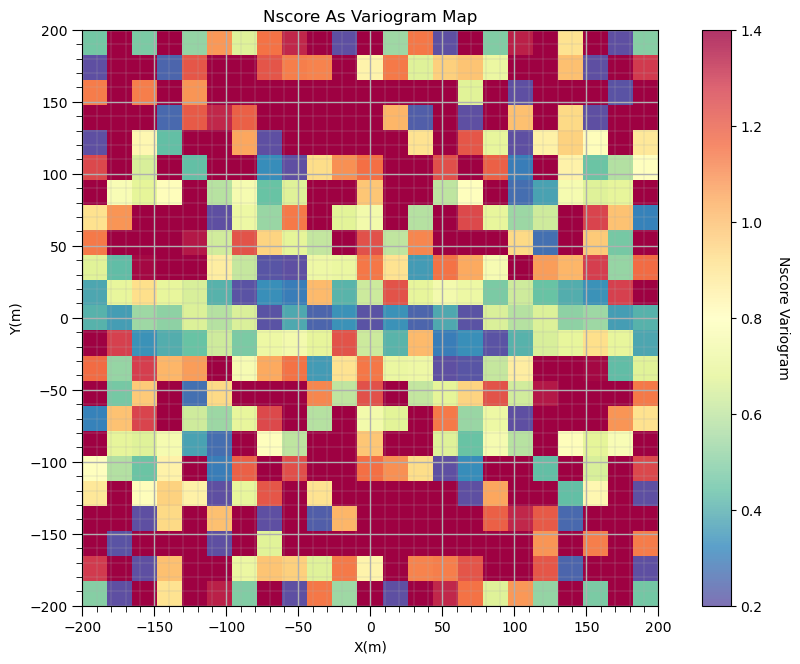

The shape of the output is (23, 23)


In [27]:
vmap, npmap = geostats.varmapv(df_As,'EAST','NORTH','nscore',tmin=-9999,tmax=9999,nxlag=11,nylag=11,dxlag=7,dylag=50,minnp=1,isill=1)

plt.subplot(121)
GSLIB.pixelplt_st(vmap,-200,200,-200,200,50.0,0.2,1.4,'Nscore As Variogram Map','X(m)','Y(m)','Nscore Variogram',cmap)
add_grid()
plt.subplots_adjust(left=0.0, bottom=0.0, right=3.0, top=1.2, wspace=0.2, hspace=0.2)
plt.show()

print('The shape of the output is ' + str(vmap.shape))

Notice that the output ndarray is 23, 23 cells? We asked for the number of cells to extend in each direction, 11 and 11 in x and y.  The map has an origin (zero distance) cell in the middle and extends 11 in both positive and negative directions.  So we have 2*$nx$ + 1, 2*$ny$ + 1 cells in the resulting variogram map and the $xmin = -1 * (nx * x_{cellsize} + \frac{1}{2} x_{cellsize})$ and the $xmax = nx * x_{cellsize} + \frac{1}{2} x_{cellsize}$

What do you think of this variogram map? These are my observations:

* major continuity direction is at azimuth 045
* there is a high degree of geometric anisotropy
* there is cyclicity in the 135 direction 
* there may be some cyclicity in the 045 direction

From this variogram map we can immediately see directionality in our spatial data.

#### Method \#3: Experimental Variograms

Another method for exploring spatial data directionality is the calculation of multiple experimental variograms for a variety of directions.

We can use the location maps to help determine good variogram calculation parameters.

```p
tmin = -9999.; tmax = 9999.; 
lag_dist = 100.0; lag_tol = 50.0; nlag = 7; bandh = 9999.9; azi = azi; atol = 22.5; isill = 1
```
* **tmin**, **tmax** are trimming limits - set to have no impact, no need to filter the data
* **lag_dist**, **lag_tol** are the lag distance, lag tolerance - set based on the common data spacing (100m) and tolerance as 100% of lag distance for additonal smoothing
* **nlag** is number of lags - set to extend just past 50 of the data extent
* **bandh** is the horizontal band width - set to have no effect
* **azi** is the azimuth -  it has not effect since we set atol, the azimuth tolerance, to 90.0
* **isill** is a boolean to standardize the distribution to a variance of 1 - it has no effect since the nscore transform sets the variance to 1.0

In [28]:
tmin = -9999.; tmax = 9999.                             # no trimming 
lag_dist = 30.0; lag_tol = lag_dist*0.5; nlag = 40;            # maximum lag is 700m and tolerance > 1/2 lag distance for smoothing
bandh = 30; atol = 22.5                             # no bandwidth, directional variograms
isill = 1                                               # standardize sill
azi_mat = [0,22.5,45,67.5,90,112.5,135,157.5]           # directions in azimuth to consider

Let's try running these variograms and visualizing them on separate plots.  I'll demonstrate a method to promgramtically loop over each direction for efficiency (and code brevity).

* we have the direction in the list called 'azi_mat'
* we use the command:
```p
for iazi in range(0,len(azi_mat)): 
```
to loop over all the elements in the list with index 'iazi'

* we run the variogram calculation and store the reuslts in 2D arrays, iy is direction, ix is the lag
* we use subplots with the 'iazi' index to add each plot

```p
    plt.subplot(4,2,iazi+1)
```
we add one because the plot index must be $1,\ldots,n$, but arrays / list index as $0,\ldots,n-1$ in Python.

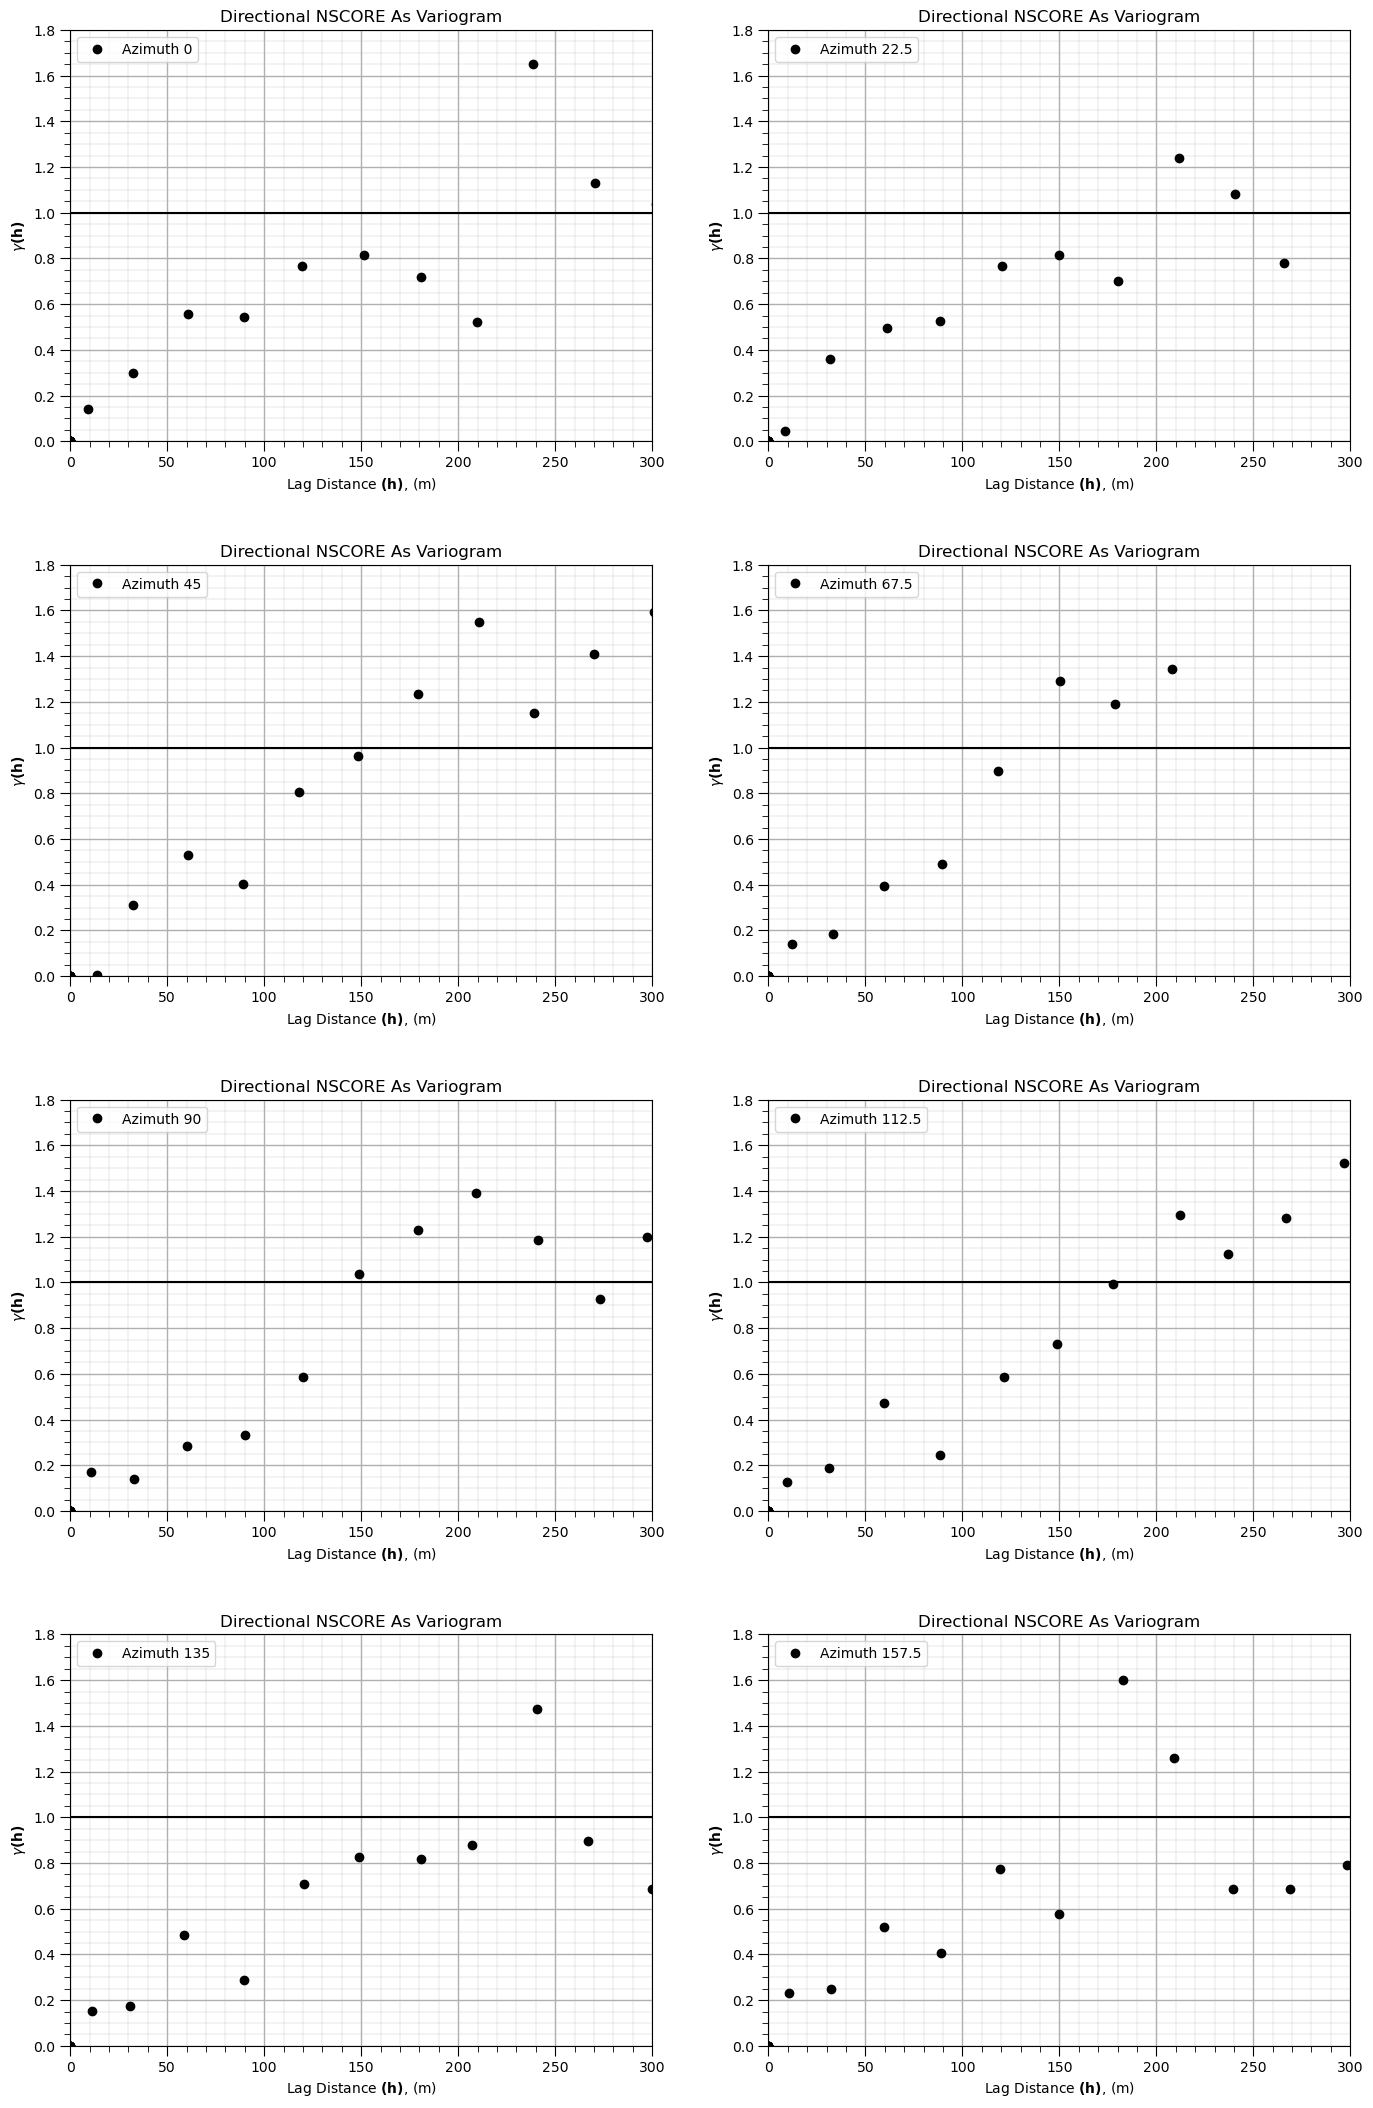

In [29]:
# Arrays to store the results
lag = np.zeros((len(azi_mat),nlag+2)); gamma = np.zeros((len(azi_mat),nlag+2)); npp = np.zeros((len(azi_mat),nlag+2));

for iazi in range(0,len(azi_mat)):                      # Loop over all directions
    lag[iazi,:], gamma[iazi,:], npp[iazi,:] = geostats.gamv(df_As,"EAST","NORTH","nscore",tmin,tmax,lag_dist,lag_tol,nlag,azi_mat[iazi],atol,bandh,isill)
    plt.subplot(4,2,iazi+1)
    plt.plot(lag[iazi,:],gamma[iazi,:],'o',color = 'black',label = 'Azimuth ' +str(azi_mat[iazi]))
    plt.plot([0,2000],[1.0,1.0],color = 'black')
    plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
    plt.ylabel(r'$\gamma \bf(h)$')
    plt.title('Directional NSCORE As Variogram')
    plt.xlim([0,300])
    plt.ylim([0,1.8])
    plt.legend(loc='upper left')
    add_grid()

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=4.2, wspace=0.2, hspace=0.3)
plt.show()

The directional variograms provide a very clear image of directionality. The ranges vary in different directions.  We are observing the actually spatial continuity ellipse by exploring a variety of directions! 

* We can observe that Azimuth 000 is the major direction and Azimuth 090 is the minor direction.

This is a very powerful tool for exploring directionality in spatial datasets.

#### Variogram Modeling

From above we can identify 045 as the major direction and 135 as the minor direction. We must build a single 2D nested variogram model based on the experiential variograms in each 045 and 135 directions.  First, let's look at these two experimental variograms again.

Below edit the following code to select the major and minor directions from the plots above.  

```python
# Select the plot above for the major and minor
imajor = 0
iminor = 4
```

Note the first plot is 0 and then step through $0, 1, \ldots, n$ where $n$ is the number of directional variograms calculated above.  For the provided example we selected the plots, 0th (000 Azimuth) for the major direction and the 4th (090 Azimuth) for the minor direction.

Major direction is 0 azimuth.
Minor direction is 90 azimuth.


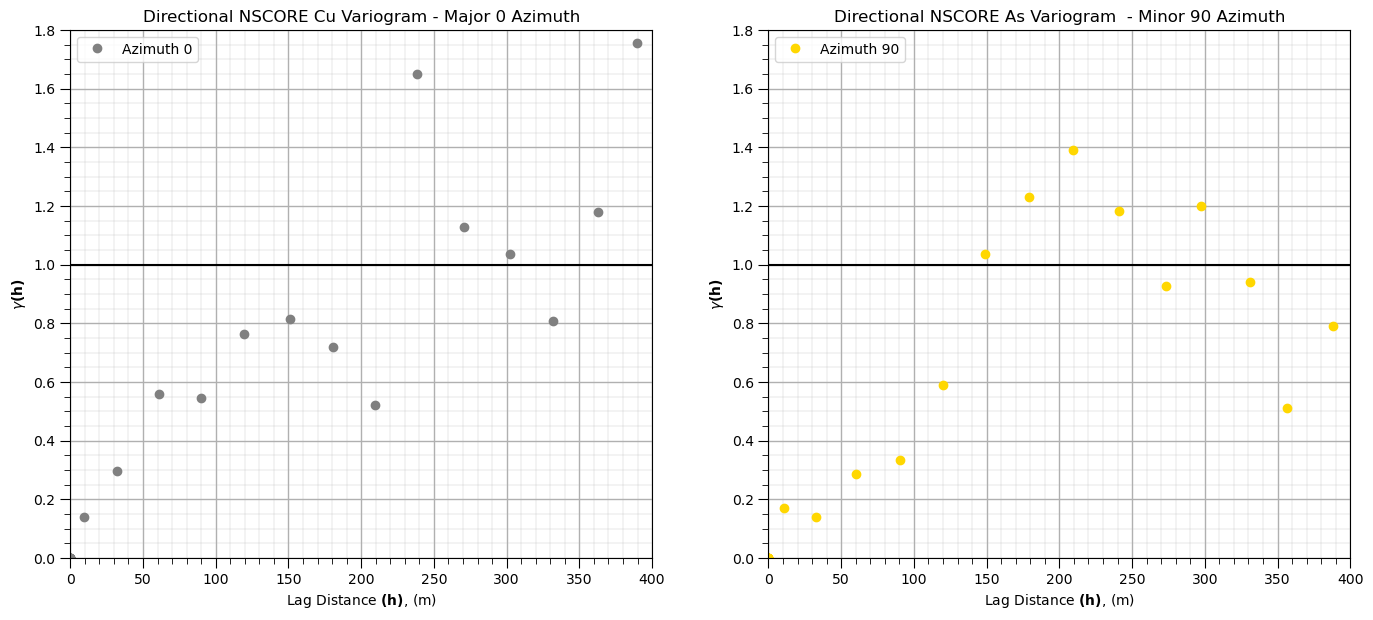

In [30]:
# Select the plot above for the major and minor
imajor = 0
iminor = 4

print('Major direction is ' + str(azi_mat[imajor]) + ' azimuth.')
print('Minor direction is ' + str(azi_mat[iminor]) + ' azimuth.')

if not abs(azi_mat[imajor] - azi_mat[iminor]) == 90.0:
    print('Major and minor directions must be orthogonal to each other.')
    sys.exit()

plt.subplot(1,2,1)
plt.plot(lag[imajor,:],gamma[imajor,:],'o',color = 'grey',label = 'Azimuth ' + str(azi_mat[imajor]))
plt.plot([0,2000],[1.0,1.0],color = 'black')
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE Cu Variogram - Major ' + str(azi_mat[imajor]) + ' Azimuth')
plt.xlim([0,400])
plt.ylim([0,1.8])
plt.legend(loc='upper left')
add_grid()
plt.subplot(1,2,2)
plt.plot(lag[iminor,:],gamma[iminor,:],'o',color = 'gold',label = 'Azimuth ' +str(azi_mat[iminor]))
plt.plot([0,2000],[1.0,1.0],color = 'black')
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE As Variogram  - Minor ' + str(azi_mat[iminor]) + ' Azimuth')
plt.xlim([0,400])
plt.ylim([0,1.8])
plt.legend(loc='upper left')
add_grid()
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.1, wspace=0.2, hspace=0.3); plt.show()

We will assume these models will be applied in sequential Gaussian simulation; therefore, we must model to the sill (or the global distribution will not be reproduced over the realizations).  We will also not use cyclicity for now, as we are just getting started.  

* Let's build a reasonable model to the sill.

##### make_variogram function

We use the make_variogram function to make a variogram model 

* a dictionary for compact storage of the variogram model parameters to pass into plotting (below), kriging and simulation methods 

The variogram model parameter include:

* **nug** - nugget effect contribution to sill
* **nst** - number of nested structures (1 or 2)
* **it** - type for this nested structure (1 - spherical, 2 - exponential, 3 - Gaussian)
* **cc** - contribution of each nested structure (contributions + nugget must sum to the sill)
* **azi** - the azimuth for this nested structure of the major direction, the minor is orthogonal
* **hmaj** - the range for this nested structure in the major direction
* **hmin** - the range for this nested structure in the minor direction

We increment it, cc, azi, hmaj, and hmin for the 1st and 2nd structures

* for only 1 structure plus optional nugget, omit the 2nd structure parameters and they will default to $cc2 = 0$, no contribution to the model

Here's my model:

```p
nug = 0.3; nst = 2                                             # 2 nest structure variogram model parameters
it1 = 1; cc1 = 0.2; azi1 = azi_mat[imajor]; hmaj1 = 120; hmin1 = 70 #first structure
it2 = 1; cc2 = 0.5; azi2 = azi_mat[imajor]; hmaj2 = 370; hmin2 = 200 #second structure
```

Some comments on our model:

* we model to the sill of 1.0, since we applied the normal score transform ($nug + cc1 + cc2 = 1.0$)

* we used 2 spherical structures to capture zontal anisotropy in the 045 azimuth

* since the experimental variogram exceeds the sill with trend or cyclicity we could have attempted trend modeling and then worked with the residual, but we will not do this for workflow brevity and simplicity

We input these model parameters to make a variogram model dictionary with the make_variogram function as follows:

```p
vario = GSLIB.make_variogram(nug,nst,it1,cc1,azi1,hmaj1,hmin1,it2,cc2,azi2,hmaj2,hmin2)
```

##### vmodel function

To plot the variogram we use the vmodel function to project the model in the major and minor directions

The inputs for vmodel are:

* **nlag** - the number of points along the variogram to calculate for the projection

* **xlag** - the size of a lag for the projection

* **azm** - the direction of the projection in azimuth (this is all we need since we are working in 2D)

* **vario** - the variogram model dictionary from the make_variogram function (above)

Note: this function is just for visualization by projecting the variogram model in a direction, so the convention is to use a very small **xlag** and large **nlag** for a high resolution display of the variogram model

The outputs from the vmodel program include:

* **index** - the lag number for the projection

* **lag distance** - the distance offset along the projection (the **h** in the variogram plot)

* **variogram** - the variogram value at the lag distance for the projection (the $\gamma$(**h**) in the variogram plot)

* **covariance function** - the covariance function at the lag distance for the projection (for the C(**h**) plot)

* **correlogram** - the correlogram at the lag distance for the projection (for the $\rho$(**h**) plot)

We have 2 structures and no nugget effect.  We needed the 2nd structure to capture the zonal anisotropy in the 045 direction.  Let's calculate the variogram model in these directions and plot them with the experimental variograms.   

#### Spherical Variogram Model

A very commonly observed variogram / spatial continuity form in many settings

* Peicewise, beyond the range is equal to the sill

The equation:

$$
\gamma(\bf{h} ) = c_1 \cdot \text{Sph} \left( \frac{\bf{h} }{a} \right) =
\left\{ 
  \begin{array}{ c l }
    c_1 \cdot \left[ 1.5 \left( \frac{\bf{h} }{a} \right) -  0.5 \left( \frac{\bf{h} }{a} \right)^3 \right] & h < a \\
    c_1 & h \ge a
  \end{array}
\right.
$$

where $𝑐_1$ is the contribution, $𝑎$ is the range and $\bf{𝐡}$ is the lag distance

#### Nugget Effect Variogram Model

No spatial correlation

* Does not have a range, nor directionality, i.e., acts over all distances and directions.

Should be a small component of the overall variance
* Very uncommon in siliclastic sedimentary systems
* More common for mineral grades in mining
* May be measurement error

The equation:

$$
\gamma(\bf{h} ) = c_1 \cdot \text{Nugget} =
\left\{ 
  \begin{array}{ c l }
    0 & h = 0 \\
    c_1 & h > 0
  \end{array}
\right.
$$

where $𝑐_1$ is the contribution, and $h$ is the lag distance

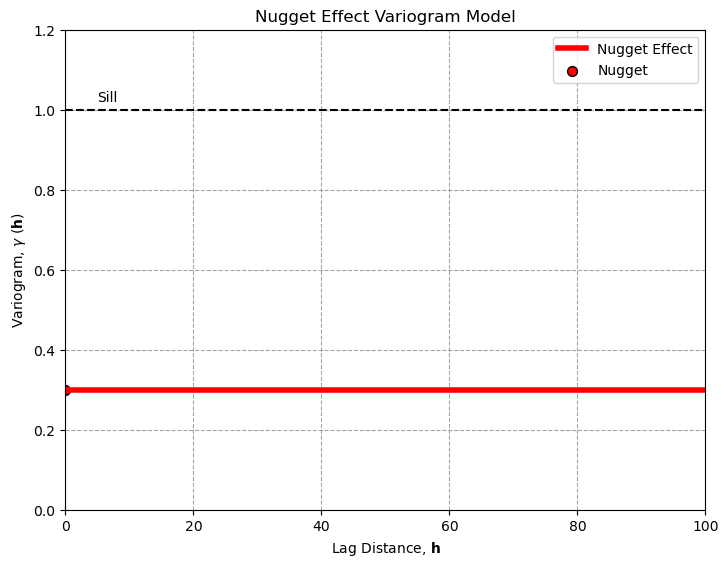

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Define the nugget effect
nugget_value = 0.3
gamma_nugget = np.ones(101) * nugget_value                    # nugget effect set to 0.3
h = np.linspace(0, 400, 101)                                  # lag distance vector

plt.figure(figsize=(8, 6))

# Plot the nugget effect line (horizontal line)
plt.plot(h, gamma_nugget, color='red', lw=4, label='Nugget Effect')

# Plot the sill line
plt.plot([0, 100], [1.0, 1.0], color='black', ls='--')
plt.annotate('Sill', xy=(5, 1.02))

# Plot the nugget point at lag distance 0
plt.scatter(0, nugget_value, color='red', edgecolor='black', s=50, label='Nugget')

# Set the limits and labels
plt.xlim([0, 100])
plt.ylim([0, 1.2])
plt.xlabel(r'Lag Distance, $\bf{h}$')
plt.ylabel(r'Variogram, $\gamma$ ($\bf{h}$)')
plt.title('Nugget Effect Variogram Model')

# Add grid and legend
plt.grid(True, linestyle='--', color='grey', alpha=0.7)
plt.legend()

plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.2, hspace=0.2)
plt.show()


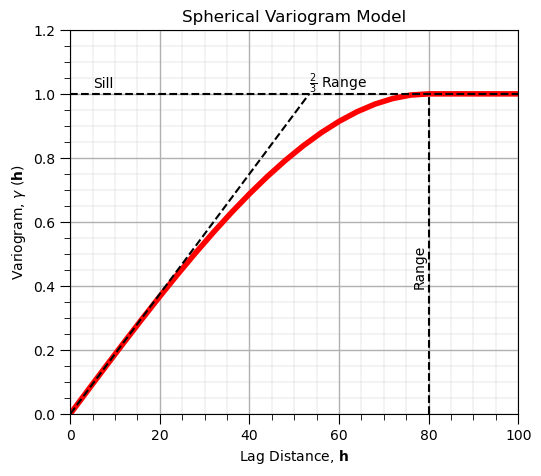

In [32]:
vrange = 80                                                   # range parameter

gamma_sph = 1.0*(1.5*h/vrange) - 0.5*np.power(h/vrange,3)     # spherical model
gamma_sph[h > vrange] = 1.0

plt.subplot(111)
plot = plt.plot(h,gamma_sph,color='red',lw=4)
plt.plot([0,100],[1.0,1.0],color='black',ls='--'); plt.annotate('Sill',[5,1.02])
plt.plot([0,vrange*2/3],[0,1.0],color='black',ls='--'); plt.annotate(r'$\frac{2}{3}$ Range',[vrange*2/3,1.02])
plt.plot([vrange,vrange],[0.0,1.0],color='black',ls='--'); plt.annotate('Range',[vrange-3.5,0.4],rotation=90.0)
gca = plt.gca()
plt.xlim([0,100]); plt.ylim([0,1.2])
plt.xlabel(r'Lag Distance, $\bf{h}$'); plt.ylabel(r'Variogram, $\gamma$ ($\bf{h}$)')
plt.title('Spherical Variogram Model'); add_grid()

plt.subplots_adjust(left=0.0, bottom=0.0, right=0.7, top=0.8, wspace=0.2, hspace=0.2); plt.show()

#### Exponential Variogram Model

Also very commonly observed variogram / spatial continuity form

* Less short-scale continuity than spherical, and reaches sill asymptotically, range is at 95% of the sill 

The equation:

$$
\gamma( \bf{h} ) = c_1 \cdot \text{ Exp } \left( \frac{ \bf{h} }{𝑎} \right) = c_1 \cdot \left[ 1.0 − \text{exp} \left(−3 \cdot \left( \frac{ \bf{h} }{𝑎} \right) \right) \right]
$$

where $𝑐_1$ is the contribution, $𝑎$ is the range and $\bf{h}$ is the lag distance.

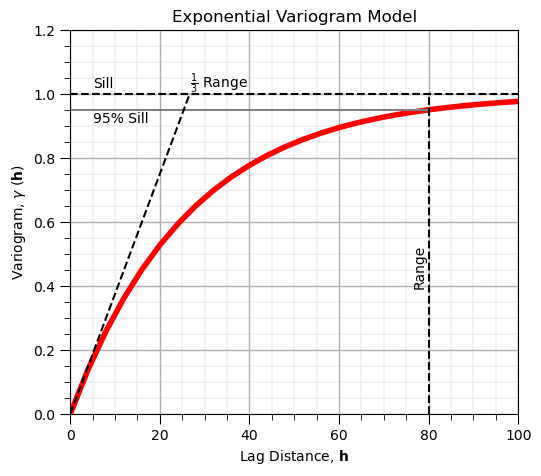

In [33]:
vrange = 80                                                   # range parameter

gamma_exp = 1.0*(1.0-np.exp(-3*(h/vrange)))                   # exponential model

plt.subplot(111)
plot = plt.plot(h,gamma_exp,color='red',lw=4)
plt.plot([0,100],[1.0,1.0],color='black',ls='--'); plt.annotate('Sill',[5,1.02])
plt.plot([0,vrange],[0.95,0.95],color='grey',ls='-'); plt.annotate('95% Sill',[5,0.91])
plt.plot([vrange,vrange],[0.0,1.0],color='black',ls='--'); plt.annotate('Range',[vrange-3.5,0.4],rotation=90.0)
plt.plot([0,vrange*1/3],[0,1.0],color='black',ls='--'); plt.annotate(r'$\frac{1}{3}$ Range',[vrange*1/3,1.02])
gca = plt.gca()
plt.xlim([0,100]); plt.ylim([0,1.2])
plt.xlabel(r'Lag Distance, $\bf{h}$'); plt.ylabel(r'Variogram, $\gamma$ ($\bf{h}$)')
plt.title('Exponential Variogram Model'); add_grid()

plt.subplots_adjust(left=0.0, bottom=0.0, right=0.7, top=0.8, wspace=0.2, hspace=0.2); plt.show()

#### Gaussian Variogram Model

Less commonly observed variogram / spatial continuity form, e.g., for thickness and elevation

* Much more short-scale continuity than spherical, and reaches sill asymptotically, range is at 95% of the sill 

The equation:

$$
\gamma( \bf{h} ) = c_1 \cdot \text{ Gaus } \left( \frac{ \bf{h} }{𝑎} \right) = c_1 \cdot \left[ 1.0 − \text{exp} \left(−3 \cdot \left( \frac{ \bf{h} }{𝑎} \right)^2 \right) \right]
$$

where $𝑐_1$ is the contribution, $𝑎$ is the range and $\bf{h}$ is the lag distance.

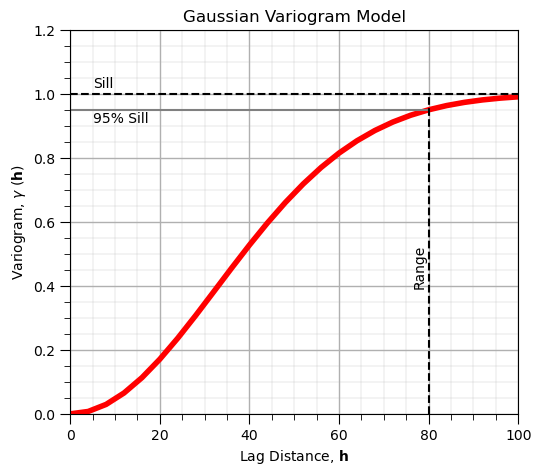

In [34]:
vrange = 80                                                   # range parameter

gamma_gaus = 1.0*(1.0-np.exp(-3*np.power(h/vrange,2)))        # Gaussian model

plt.subplot(111)
plot = plt.plot(h,gamma_gaus,color='red',lw=4)
plt.plot([0,100],[1.0,1.0],color='black',ls='--'); plt.annotate('Sill',[5,1.02])
plt.plot([0,vrange],[0.95,0.95],color='grey',ls='-'); plt.annotate('95% Sill',[5,0.91])
plt.plot([vrange,vrange],[0.0,1.0],color='black',ls='--'); plt.annotate('Range',[vrange-3.5,0.4],rotation=90.0)
gca = plt.gca()
plt.xlim([0,100]); plt.ylim([0,1.2])
plt.xlabel(r'Lag Distance, $\bf{h}$'); plt.ylabel(r'Variogram, $\gamma$ ($\bf{h}$)')
plt.title('Gaussian Variogram Model'); add_grid()

plt.subplots_adjust(left=0.0, bottom=0.0, right=0.7, top=0.8, wspace=0.2, hspace=0.2); plt.show()

 x,y,z offsets = 0.0,10.0
 x,y,z offsets = 10.0,1.794896514920806e-08


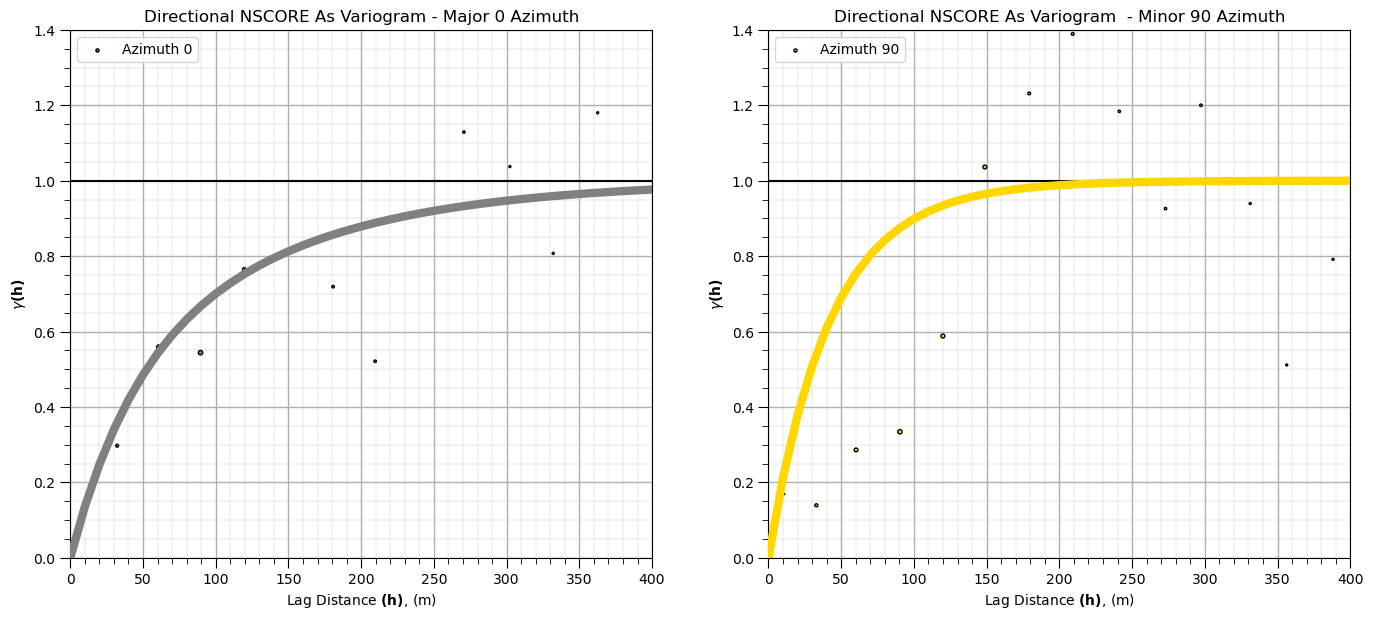

In [35]:
nug = 0.0; nst = 2                                             # 2 nest structure variogram model parameters
it1 = 2; cc1 = 0.4; azi1 = azi_mat[imajor]; hmaj1 = 120; hmin1 = 100
it2 = 2; cc2 = 0.6; azi2 = azi_mat[imajor]; hmaj2 = 370; hmin2 = 150

vario = GSLIB.make_variogram(nug,nst,it1,cc1,azi1,hmaj1,hmin1,it2,cc2,azi2,hmaj2,hmin2) # make model object
nlag = 70; xlag = 10;                                          # project the model in the 045 azimuth
index_maj,h_maj,gam_maj,cov_maj,ro_maj = geostats.vmodel(nlag,xlag,azi_mat[imajor],vario)                                                     # project the model in the 135 azimuth
index_min,h_min,gam_min,cov_min,ro_min = geostats.vmodel(nlag,xlag,azi_mat[iminor],vario)

plt.subplot(1,2,1)
plt.scatter(lag[imajor,:],gamma[imajor,:],color = 'grey',edgecolor='black',s=npp[imajor,:]/20,marker='o',label = 'Azimuth ' +str(azi_mat[imajor]))
plt.plot([0,2000],[1.0,1.0],color = 'black')
plt.plot(h_maj,gam_maj,color='grey',lw=6,zorder=60)
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE As Variogram - Major ' + str(azi_mat[imajor]) + ' Azimuth')
plt.xlim([0,400])
plt.ylim([0,1.4])
plt.legend(loc='upper left')
add_grid()

plt.subplot(1,2,2)
plt.scatter(lag[iminor,:],gamma[iminor,:],color = 'gold',edgecolor='black',s=npp[iminor,:]/20,marker='o',label = 'Azimuth ' +str(azi_mat[iminor]))
plt.plot([0,2000],[1.0,1.0],color = 'black')
plt.plot(h_min,gam_min,color='gold',lw=6,zorder=60,)
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE As Variogram  - Minor ' + str(azi_mat[iminor]) + ' Azimuth')
plt.xlim([0,400])
plt.ylim([0,1.4])
plt.legend(loc='upper left')
add_grid()
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.1, wspace=0.2, hspace=0.3); plt.show()

# Week 3 Assignment

# Week 3 Practical: Declustering, Normal Scores, and Variography (Cu %)

**Context.** You are given point‐sample Copper grades expressed in **percent (%)** with X–Y (and, if available, Z) coordinates. The goal this week is to correct for spatial sampling bias via **cell declustering**, compare naïve vs. declustered statistics, transform grades to **Gaussian (normal) scores**, compute an **experimental variogram**, and **fit** a suitable model (choose from **Spherical, Exponential, Gaussian**).

> ✅ **Deliver everything in a single Jupyter notebook.** Use clear section headings, show intermediate diagnostics (plots + tables), and finish with a short written report (template provided at the end).


## Learning outcomes

By the end of this practical you should be able to:

1. Explain why clustered sampling biases global statistics, and correct it with **cell declustering**.
2. Compute and compare **naïve** vs **declustered** mean, variance, and histogram.
3. Map empirical Cu% values to **normal scores** using the **normal score transform** and check the result.
4. Build an **experimental variogram** from normal scores, with sensible lag parameters.
5. **Fit** a Spherical, Exponential, and Gaussian **variogram model**, justify your choice, and report the parameters (nugget, sill, range).


## Data & setup

* Input table must contain at least: `x`, `y`, `Cu_pct`. If `z` exists, ignore for this week (2D).
* Keep grades in **% units** for declustering and summary stats. For variography, use **normal scores**.
* Recommended packages: `numpy`, `pandas`, `scipy`, `matplotlib`. (Optional: `gstools` or `scikit-gstat`.)



## Task 1: Cell declustering (de-biasing)

**Why.** Clustered sampling (e.g., near roads or pits) overweights those zones and biases global stats.

**Method (grid-based cell declustering).**

1. Choose a **cell size** close to **half the average nearest‐neighbour distance**. Tip: compute NND and use its median; try a few sizes around that value (sensitivity check).
2. Overlay a regular grid; count samples per cell.
3. Assign each sample a weight
   $
   w_i ;=; \frac{1}{n_c} \quad \text{for sample } i \text{ in cell } c,\quad \text{then normalise } \sum_i w_i = 1.
   $
4. **Sensitivity:** Pick the size that stabilises the weighted mean.

**Outputs.**

* Scatter plot of sample locations colour‐coded by weight (heavier in sparse areas).
* Table of naïve vs declustered stats: mean, std, min, p10, p50, p90, max.
* Overlaid histograms of Cu%: naïve (equal weights) vs declustered (w_i).



## Task 2: Normal score transform (to Gaussian)

**Why.** Variogram modelling and many geostatistical methods assume normality.

**Steps.**

1. Compute the **empirical CDF** of Cu% using **rank‐based** probabilities
   $
   p_i = \frac{\text{rank}(z_i) - 0.5}{N},
   $
   using average ranks for ties.
2. Map to normal scores
   $
   y_i ;=; \Phi^{-1}(p_i),
   $
   where $\Phi^{-1}$ is the standard normal quantile.


## Task 3: Experimental variogram

Compute the semivariance on **normal scores** (y):

$
\gamma(h) ;=; \frac{1}{2,N(h)} \sum_{(i,j)\in \mathcal{P}(h)} \bigl(y(\mathbf{x}_i)-y(\mathbf{x}_j)\bigr)^2,
$

where $\mathcal{P}(h)$ are all pairs whose separation falls into the lag bin for distance (h).


**Outputs.** Experimental semi-variogram plots.


## Task 4: Variogram model fitting & selection

Fit **all three** models to the experimental variogram (on normal scores) and select the best with a clear justification.

**Models (nested form with single or double structure is fine this week):**

* **Spherical**
  $
  \gamma(h) = C_0 + C\left[ \tfrac{3}{2}\tfrac{h}{a} - \tfrac{1}{2}\Bigl(\tfrac{h}{a}\Bigr)^3 \right] \ \text{for } h\le a,\quad
  \gamma(h) = C_0 + C \ \text{for } h > a.
  $

* **Exponential**
  $
  \gamma(h) = C_0 + C\left(1 - e^{-h/a}\right),
  \quad \text{practical range } \approx 3a.
  $

* **Gaussian**
  $
  \gamma(h) = C_0 + C\left(1 - e^{-(h/a)^2}\right),
  \quad \text{practical range } \approx \sqrt{3},a.
  $

Here $C_0$ = **nugget**, $C$ = **structured sill contribution**, $C_0+C$ = **total sill**, $a$ = **range parameter**.

**Fitting hints.**

* Initial guesses:

  * $C_0$ ≈ first‐lag $\gamma$ (or 10–20% of total sill if noisy)
  * total sill ≈ 1


**Outputs.** Variogram plot with empirical points and all three fitted curves; a small table of fitted parameters per model.


## What to hand in (minimum)

1. **Notebook sections:**

   * Data load and quick EDA (spatial scatter; histogram of Cu%).
   * **Cell declustering** (weights map; naïve vs declustered summary and histograms; sensitivity to cell size).
   * **Normal score transform** (histogram PDF and CDF‐plot, (z) vs (y)).
   * **Experimental variograms** (plots).
   * **Model fitting** (Spherical, Exponential, Gaussian; parameter table; final chosen model).
2. **Figures**: clear axis labels/units; legends; readable fonts.
3. **Markdown report** at the very end (use the template below).


### Submission checklist

* [ ] Notebook runs top-to-bottom without errors.
* [ ] All plots/tables are labelled and legible.
* [ ] Final Markdown report completed.

Good luck! and remember: **show your working**, not just final numbers.
